# Détermination expérimentale de Vmax et Km

Quand on ne connait pas les valeurs de $V_{max}$ et $K_m$ pour une enzyme et un substrat donnés, on peut les déterminer expérimentalement, notamment en mesurant la vitesse initiale de cinétique pour différentes concentrations initiales de substrat. Nous allons simuler cette approche numériquement avec Python.

En reprenant la loi de Michaelis-Menten, la vitesse initiale de la réaction enzymatique, $v_0$, s'exprime en fonction de la concentration initiale en substrat $[S]_0$ selon :

$$
v_0 = \frac{V_{max} \times [S]_0}{K_m + [S]_0}
$$

On réalise 10 cinétiques avec des concentrations initiales en substrat différentes, et pendant lesquelles on mesure la concentration du produit en fonction du temps.

Voici les différentes concentrations initiales en substrat pour chaque expérience :

| expérience | $[S]_0$ (µM) | 
|:---------:|:------------:|
|         1 | $1,00.10^{-4}$ |
|         2 | $2,50.10^{-4}$ |
|         3 | $4,50.10^{-4}$ |
|         4 | $6,00.10^{-4}$ |
|         5 | $1,20.10^{-3}$ |
|         6 | $2,40.10^{-3}$ |
|         7 | $3,00.10^{-3}$ |
|         8 | $9,00.10^{-3}$ |
|         9 | $1,80.10^{-2}$ |
|        10 | $3,00.10^{-2}$ |

La variable `S0_exp` contient ces différentes concentrations initiales :

In [1]:
S0_exp =  [1.00e-04, 2.50e-04, 4.50e-04, 6.00e-04, 1.20e-03, 2.40e-03, 3.00e-03, 9.00e-03, 1.80e-02, 3.00e-02]

:::{admonition} Note
:class: note

En Python, la puissance de 10 utilisée dans l'écriture scientifique s'écrit `e`.

Ainsi :

- 100 soit $10^{2}$ s'écrit `1e2`
- 10 000 soit $10^{4}$ s'écrit `1e4`
- 3 200 soit $3,2.10^{3}$ s'écrit `3.2e3`
- 0,078 soit $7,8.10^{-2}$ s'écrit `7.8e-2`
- 0,00025 soit $2,5.10^{-4}$ s'écrit `2.5e-5`

Ici, `e` désigne la puissance 10. En Python, la fonction exponentielle $e$ est notée `exp()`.

:::

## Lecture des données expérimentales

Les fichiers `exp1.txt` à `exp10.txt` contiennent les mesures expérimentales de la concentration en produit en fonction du temps pour les différentes valeurs de $[S]_0$. Voici les premières lignes du fichiers `exp1.txt` :

```none
0.25,2.190e-05
0.50,3.992e-05
0.75,5.450e-05
1.00,6.592e-05
1.25,7.521e-05
1.50,8.172e-05
1.75,8.679e-05
2.00,9.034e-05
```

Chaque ligne contient le temps exprimé en minutes suivi de la concentration du produit en µM. Les valeurs de temps et de concentration du produit sont séparées par une virgule.

Ainsi, la première mesure (`0.25`) a été réalisée à 0,25 minute soit 15 secondes et la concentration du produit mesurée (`2.190e-05`) est de $2,190.10^{-5}$ µM.

Ouvrez tous les fichiers `exp1.txt` à `exp10.txt` en double-cliquant sur leur nom respectif dans l'explorateur de fichier (à gauche) :

- Vérifiez que tous les fichiers contiennent le même nombre de lignes.
- À quel temps a eu lieu la première mesure ?
- À quel temps a eu lieu la dernière mesure ?
- Quel est l'intervalle de temps entre deux mesures successives ?

:::{admonition} Éléments de réponse
:class: tip
:class: dropdown

A priori chaque fichier doit contenir 60 lignes de données, avec des temps allant de 0,25 minute à 15 min, par pas de 0,25 min (15 secondes).

:::

La fonction `read_data()` ci-dessous prend comme argument un nom de fichier et renvoie deux listes qui correspondent aux temps de mesure et aux concentrations de produit mesurées :

In [2]:
def lit_donnees(nom_fichier):
    temps = []
    concentration_produit = []
    with open(nom_fichier, "r") as data_file:
        for line in data_file:
            # L'instruction .strip() supprime le retour à la ligne "\n".
            # L'instruction .split(",") découpe la ligne en deux chaînes de caractères.
            data = line.strip().split(",")
            temps.append(float(data[0]))
            concentration_produit.append(float(data[1]))
    return temps, concentration_produit

Si on souhaite, par exemple, lire les données de l'expérience 3 :

In [3]:
temps, conc_produit_exp_3 = lit_donnees("exp3.txt")

Dans la cellule ci-dessous, affichez les tailles des listes `temps` et `conc_produit` renvoyées par la fonction `lit_donnees()`.

- Ces deux tailles sont-elles les mêmes, pourquoi ?
- Ces tailles sont-elles cohérentes avec vos précédentes observations ?

:::{admonition} Éléments de réponse
:class: tip
:class: dropdown

Exemple de code possible :

```python
print(len(temps))
print(len(conc_produit_exp_3))
```

Réponse attendue :

```none
60
60
```

Les tailles des deux listes sont identiques car à chaque temps est associée une mesure de concentration en produit.

Par ailleurs, chaque liste contient 60 éléments, qui correspond aux 60 lignes de données observées précédemment dans les fichiers de données.

:::

Complétez la cellule de code ci-dessous, pour afficher graphiquement l'évolution de la concentration du produit en fonction du temps pour l'expérience 3 :

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline


:::{admonition} Éléments de réponse
:class: tip
:class: dropdown

Exemple de code possible :

```python
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots()
ax.set_xlabel("Temps (min)")
ax.set_ylabel("[P] (µM)")
ax.plot(temps, conc_produit_exp_3, label="Expérience 3")
ax.scatter(temps, conc_produit_exp_3)
ax.legend()
plt.show()
```

:::

Nous allons maintenant comparer les expériences 2 et 4. Exécutez la cellule de code ci-dessous pour lire les fichiers de données de ces expériences :

In [ ]:
temps, conc_produit_exp_2 = lit_donnees("exp2.txt")
temps, conc_produit_exp_4 = lit_donnees("exp4.txt")

Pourquoi utilise-t-on la même variable `temps` pour stocker le temps des mesures et pas deux variables distinctes (par exemple `temps_exp_2` et `temps_exp_4`) pour chaque expérience ?

:::{admonition} Éléments de réponse
:class: tip
:class: dropdown

Les mesures de concentration de produit ont été réalisées exactement aux mêmes temps pour toutes les expériences.

On peut donc stocker ces différents temps dans une unique variable.

:::

Dans la cellule de code ci-dessous, représentez sur le même graphique l'évolution de la concentration du produit en fonction du temps pour les expériences 2 (en vert) et 4 (en rouge).

:::{admonition} Éléments de réponse
:class: tip
:class: dropdown

Exemple de code possible :

```python
fig, ax = plt.subplots()
ax.set_xlabel("Temps (min)")
ax.set_ylabel("[P] (µM)")
ax.plot(temps, conc_produit_exp_2, color="green", label="Expérience 2")
ax.scatter(temps, conc_produit_exp_2, color="green")
ax.plot(temps, conc_produit_exp_4, color="red", label="Expérience 4")
ax.scatter(temps, conc_produit_exp_4, color="red")
ax.legend()
plt.show()
```

Remarque : comme le module `matplotlib` a déjà été chargé plus tôt dans le *notebook*, les instructions suivantes ne sont plus nécessaires :

```python
import matplotlib.pyplot as plt
%matplotlib inline
````

:::

## Détermination graphique de Vmax et Km

### Méthode directe

Pour déterminer les valeurs de $V_{max}$ et $K_m$, on s'appuie sur la loi de Michaelis-Menten :

$$
v_0 = \frac{V_{max} \times [S]_0}{K_m + [S]_0}
$$

Pour chaque expérience, nous connaissons déjà $[S]_0$. Il nous reste maintenant à déterminer la vitesse initiale de la réaction enzymatique, $v_0$.

Pour cela, on réalise une régression linéaire sur les premiers points expérimentaux de la courbe de la concentration du produit en fonction du temps. La pente de la droite sera alors $v_0$.

Pour réaliser cette régression linéaire automatiquement avec Python, nous allons utiliser la bibliothèque `scipy` qui est un module Python dédié au calcul scientifique. En l'occurrence, nous allons charger le sous-module `stats` de ce module :

In [5]:
from scipy import stats

La cellule de code suivante réalise la régression linéaire de concentration du produit en fonction du temps pour l'expérience 3 :

In [6]:
pente_exp_3, ordonnee_origine_exp_3, r_value, p_value, std_err = stats.linregress(temps[:5], conc_produit_exp_3[:5])
print(f"v0 exp 3 = {pente_exp_3:.2e} µM/min")

v0 exp 3 = 1.81e-04 µM/min


:::{admonition} Note
:class: note

On réalise la régression linéaire sur les 5 premiers points de la courbe (`temps[:5]` et `conc_produit_exp_3[:5]`) pour rester sur la partie linéaire de la courbe.

Les valeurs `r_value`, `p_value` et `std_err` sont des mesures statistiques de l'adéquation de la régression linéaire avec les points expérimentaux. Nous ne les détaillerons pas ici.

:::

Pour représenter graphiquement la droite de régression, on peut calculer la concentration attendue en produit pour ce modèle linéaire :

In [7]:
conc_produit_exp_3_theorique = []
for index in range(len(temps)):
    conc_produit_exp_3_theorique.append(temps[index] * pente_exp_3 + ordonnee_origine_exp_3)

Puis afficher les valeurs théoriques avec les valeurs expérimentales :

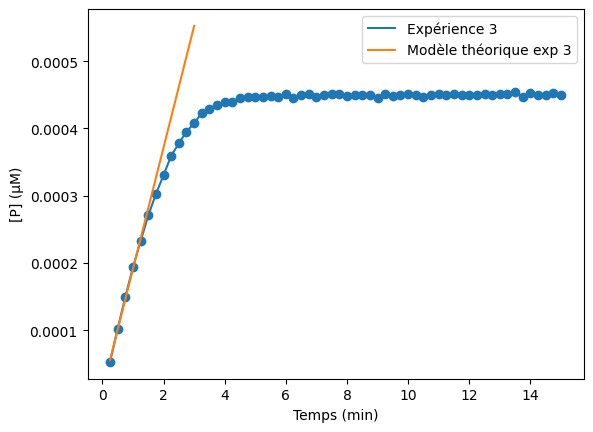

In [8]:
fig, ax = plt.subplots()
ax.set_xlabel("Temps (min)")
ax.set_ylabel("[P] (µM)")
ax.plot(temps, conc_produit_exp_3, label="Expérience 3")
ax.scatter(temps, conc_produit_exp_3)
ax.plot(temps[:12], conc_produit_exp_3_theorique[:12], label="Modèle théorique exp 3")
ax.legend()
plt.show()

:::{admonition} Note
:class: note

On affiche cette fois les 12 premières valeurs du modèle théorique car on souhaite rester sur le début de la courbe (la partie linéaire). Afficher les valeurs théoriques pour des temps grands n'a pas de sens.

:::

Dans la cellule de code ci-dessous :

- Calculez les vitesses initiales de la réaction enzymatique pour les expériences 2 et 4.
- Affichez ces vitesses initiales.


:::{admonition} Éléments de réponse
:class: tip
:class: dropdown

Soyez vigilant aux noms de vos variables quand vous réalisez des copiés-collés. Pensez à les mettre à jour partout où cela est nécessaire.


Exemple de code possible :

```python
pente_exp_2, ordonnee_origine_exp_2, r_value, p_value, std_err = stats.linregress(temps[:5], conc_produit_exp_2[:5])
print(f"v0 exp 2 = {pente_exp_2:.2e} µM/min")

pente_exp_4, ordonnee_origine_exp_4, r_value, p_value, std_err = stats.linregress(temps[:5], conc_produit_exp_4[:5])
print(f"v0 exp 4 = {pente_exp_4:.2e} µM/min")
```

Résultats attendus :

```python
v0 exp 2 = 1.22e-04 µM/min
v0 exp 4 = 2.06e-04 µM/min
````

:::

Dans la cellule de code ci-dessous :

- Représentez graphiquement l'évolution de la concentration en produit en fonction du temps pour les expériences 2 (en vert) et 4 (en rouge)
- Sur le même graphique, ajoutez les droites de régression pour les 10 premières valeurs de temps, pour les expériences 2 (en orange) et 4 (en rose).

:::{admonition} Éléments de réponse
:class: tip
:class: dropdown

Exemple de code possible :

```python
conc_produit_exp_2_theorique = []
conc_produit_exp_4_theorique = []
for index in range(len(temps)):
    conc_produit_exp_2_theorique.append(temps[index] * pente_exp_2 + ordonnee_origine_exp_2)
    conc_produit_exp_4_theorique.append(temps[index] * pente_exp_4 + ordonnee_origine_exp_4)
    
fig, ax = plt.subplots()
ax.set_xlabel("Temps (min)")
ax.set_ylabel("[P] (µM)")
ax.plot(temps, conc_produit_exp_2, color="green", label="Expérience 2")
ax.scatter(temps, conc_produit_exp_2, color="green")
ax.plot(temps[:10], conc_produit_exp_2_theorique[:10], color="orange", label="Modèle théorique exp 2")
ax.plot(temps, conc_produit_exp_4, color="red", label="Expérience 4")
ax.scatter(temps, conc_produit_exp_4, color="red")
ax.plot(temps[:10], conc_produit_exp_4_theorique[:10], color="pink", label="Modèle théorique exp 4")
ax.legend()
plt.show()
```

:::

Nous avons calculé $v_0$ pour les expériences 2, 3 et 4. Il faut faire la même chose pour les 10 expériences. Nous allons automatiser cela sans faire de copié-collés fastidieux et source d'erreur.

Prenez le temps de comprendre ce que fait la cellule de code ci-dessous. Puis exécutez-la pour calculer $v_0$ pour toutes les expériences :

In [9]:
v0 = []
for numero_experience in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
    print(f"Expérience {numero_experience}")
    fichier_experience = f"exp{numero_experience}.txt"
    temps, concentration_produit = lit_donnees(fichier_experience)
    print(f"- lecture fichier : {fichier_experience}")
    pente, ordonnee_origine, r_value, p_value, std_err = stats.linregress(temps[:5], concentration_produit[:5])
    print(f"- calcul v0 = {pente:.2e} µM/min")
    v0.append(pente)

Expérience 1
- lecture fichier : exp1.txt
- calcul v0 = 5.30e-05 µM/min
Expérience 2
- lecture fichier : exp2.txt
- calcul v0 = 1.19e-04 µM/min
Expérience 3
- lecture fichier : exp3.txt
- calcul v0 = 1.81e-04 µM/min
Expérience 4
- lecture fichier : exp4.txt
- calcul v0 = 2.12e-04 µM/min
Expérience 5
- lecture fichier : exp5.txt
- calcul v0 = 2.71e-04 µM/min
Expérience 6
- lecture fichier : exp6.txt
- calcul v0 = 3.06e-04 µM/min
Expérience 7
- lecture fichier : exp7.txt
- calcul v0 = 3.16e-04 µM/min
Expérience 8
- lecture fichier : exp8.txt
- calcul v0 = 3.38e-04 µM/min
Expérience 9
- lecture fichier : exp9.txt
- calcul v0 = 3.45e-04 µM/min
Expérience 10
- lecture fichier : exp10.txt
- calcul v0 = 3.46e-04 µM/min


La liste `S0_exp` contient les concentrations initiales en substrat pour les 10 expériences. La liste `v0` contient les vitesses initiales de la réaction enzymatique pour ces expériences.

On représente graphiquement la vitesse initiale $v_0$ en fonction de $[S]_0$ pour les 10 expériences :

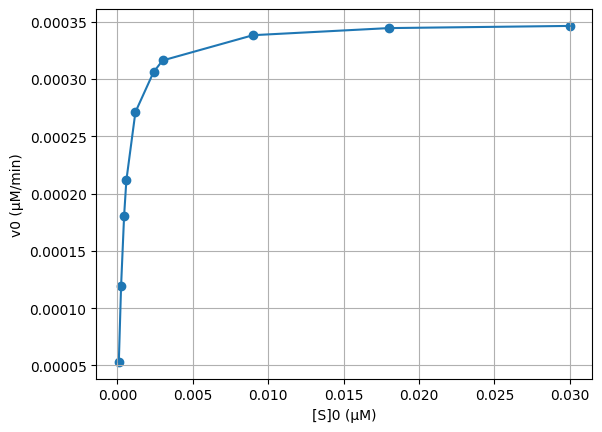

In [10]:
fig, ax = plt.subplots()
ax.set_xlabel("[S]0 (µM)")
ax.set_ylabel("v0 (µM/min)")
ax.plot(S0_exp, v0)
ax.scatter(S0_exp, v0)
ax.grid()
plt.show()

La valeur de $v_0$ quand $[S]_0$ prend des valeurs très grandes correspond à $V_{max}$.

Graphiquement, on lit $V_{max} \approx 0.00035$ soit $3,5.10^{-4}$ µM/min.

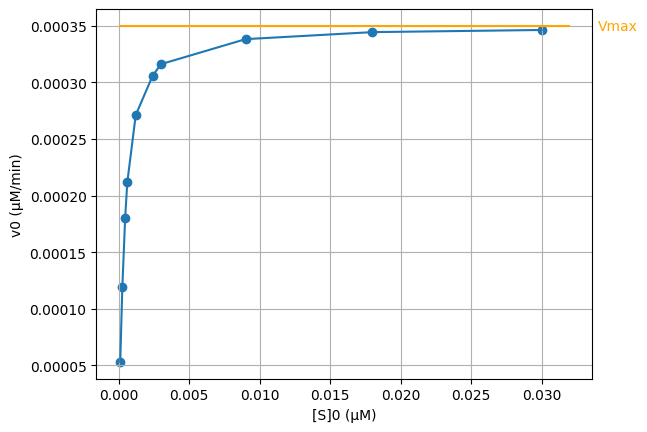

In [11]:
Vmax = 3.5e-4
fig, ax = plt.subplots()
ax.set_xlabel("[S]0 (µM)")
ax.set_ylabel("v0 (µM/min)")
ax.plot(S0_exp, v0)
ax.scatter(S0_exp, v0)
ax.hlines(Vmax, 0, 0.032, color="orange")
ax.text(0.034, Vmax, "Vmax", verticalalignment="center", color="orange")
ax.grid()
plt.show()

La valeur de $[S]_0$ pour $V_{max}/2$ donne $K_m$.

Pour déterminer graphiquement la valeur de $K_m$, on zoome sur la partie gauche de la courbe :

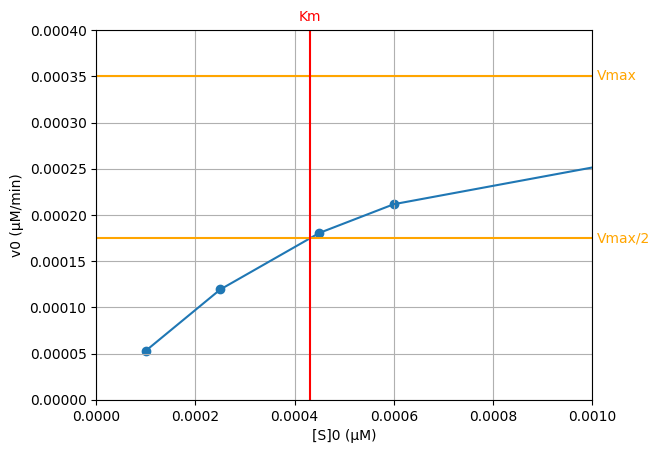

In [12]:
fig, ax = plt.subplots()
ax.set_xlabel("[S]0 (µM)")
ax.set_ylabel("v0 (µM/min)")
ax.plot(S0_exp, v0)
ax.scatter(S0_exp, v0)
ax.set_xlim(0, 1e-3)
ax.set_ylim(0, 4e-4)
ax.hlines(Vmax, 0, 0.001, color="orange")
ax.text(0.00101, Vmax, "Vmax", verticalalignment="center", color="orange")
ax.hlines(Vmax/2, 0, 0.001, color="orange")
ax.text(0.00101, Vmax/2, "Vmax/2", verticalalignment="center", color="orange")
Km = 4.3e-4
ax.vlines(Km, 0, 4e-4, color="red")
ax.text(Km, 4.1e-4, "Km", horizontalalignment="center", color="red")
ax.grid()
plt.show()

Graphiquement, on lit $K_m \approx 0.00043$ soit $4,3.10^{-4}$ µM.

Pour cet enzyme et ce substrat, les valeurs attendues sont :

- $V_{max} = 3,5.10^{-4}$ µM/min
- $K_m = 3,10^{-4}$ µM